# 🥭 Análisis EDA  — Dataset V2 Mango (Roboflow)
### Tesis — Análisis Exploratorio + Métricas de Explicabilidad (Grad-CAM)
> **Dataset:** `datasetv2-actividad3` · Workspace: `herramienta` · Versión 1  
> Este notebook realiza un EDA exhaustivo antes del entrenamiento del modelo, incluyendo análisis estadístico, detección de anomalías y métricas de explicabilidad tipo Grad-CAM.


## **1.** Instalaciones e Importaciones

In [ ]:
# ── INSTALACIONES ─────────────────────────────────────────────────────────────
!pip install roboflow opencv-python-headless matplotlib seaborn pandas numpy scikit-learn torch torchvision Pillow tqdm -q

import os, glob, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import cv2
from pathlib import Path
from collections import Counter
from PIL import Image, ImageStat
from tqdm.notebook import tqdm
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['figure.dpi'] = 120

print("Importación de librerias correctamente.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.8/195.8 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 69.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 69.3 MB/s eta 0:00:00
Importación de librerias correctamente.


## **2.** Descarga del Dataset desde Roboflow

In [ ]:
# ── DESCARGA DEL DATASET ─────────────────────────────────────────
from roboflow import Roboflow

print("=" * 65)
print("  DESCARGA DEL DATASET V2 ")
print("=" * 65)


from roboflow import Roboflow
rf = Roboflow(api_key="qsyMWg34JW523ptizLFZ")
project = rf.workspace("herramienta").project("datasetv1-actividad2")
version = project.version(3)
dataset = version.download("folder")


DATA_DIR = Path(dataset.location)
SPLITS   = ["train", "valid", "test"]

print(f"\n Dataset descargado en: {DATA_DIR}")

# Verificación rápida de estructura
for split in SPLITS:
    p = DATA_DIR / split
    if p.exists():
        classes = [d.name for d in p.iterdir() if d.is_dir()]
        n_imgs  = sum(len(list(c.glob("*.*"))) for c in p.iterdir() if c.is_dir())
        print(f"  [{split:>5}]  clases={classes}  imágenes={n_imgs}")


  DESCARGA DEL DATASET V2 
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to DatasetV1-Actividad2-3 in folder:: 100%|██████████| 3653/3653 [00:00<00:00, 4498.70it/s]


 Dataset descargado en: /content/DatasetV1-Actividad2-3
  [train]  clases=['Sanos', 'Defectuoso']  imágenes=3096
  [valid]  clases=['Sanos', 'Defectuoso']  imágenes=239
  [ test]  clases=['Sanos', 'Defectuoso']  imágenes=316


## **3.** Revisión del Dataset, número de imagenes por slip y por clase

In [ ]:
# ── INVENTARIO ────────────────────────────────────────────────────────────────
records = []

for split in SPLITS:
    split_path = DATA_DIR / split
    if not split_path.exists():
        continue
    for cls_dir in sorted(split_path.iterdir()):
        if not cls_dir.is_dir():
            continue
        imgs = list(cls_dir.glob("*.*"))
        valid_imgs = [i for i in imgs if i.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}]
        for img_path in valid_imgs:
            records.append({"split": split, "clase": cls_dir.name, "ruta": str(img_path)})

df_inv = pd.DataFrame(records)
print(f" Total de imágenes: {len(df_inv)}")
print("\nDistribución por Split y Clase:")
pivot = df_inv.groupby(["split","clase"]).size().unstack(fill_value=0)
print(pivot.to_string())
print("\n", pivot.sum(axis=0).rename("TOTAL"))


 Total de imágenes: 3651

Distribución por Split y Clase:
clase  Defectuoso  Sanos
split                   
test          163    153
train        1536   1560
valid         119    120

 clase
Defectuoso    1818
Sanos         1833
Name: TOTAL, dtype: int64


## **4.** Balance de Clases y Ratio de Desbalance

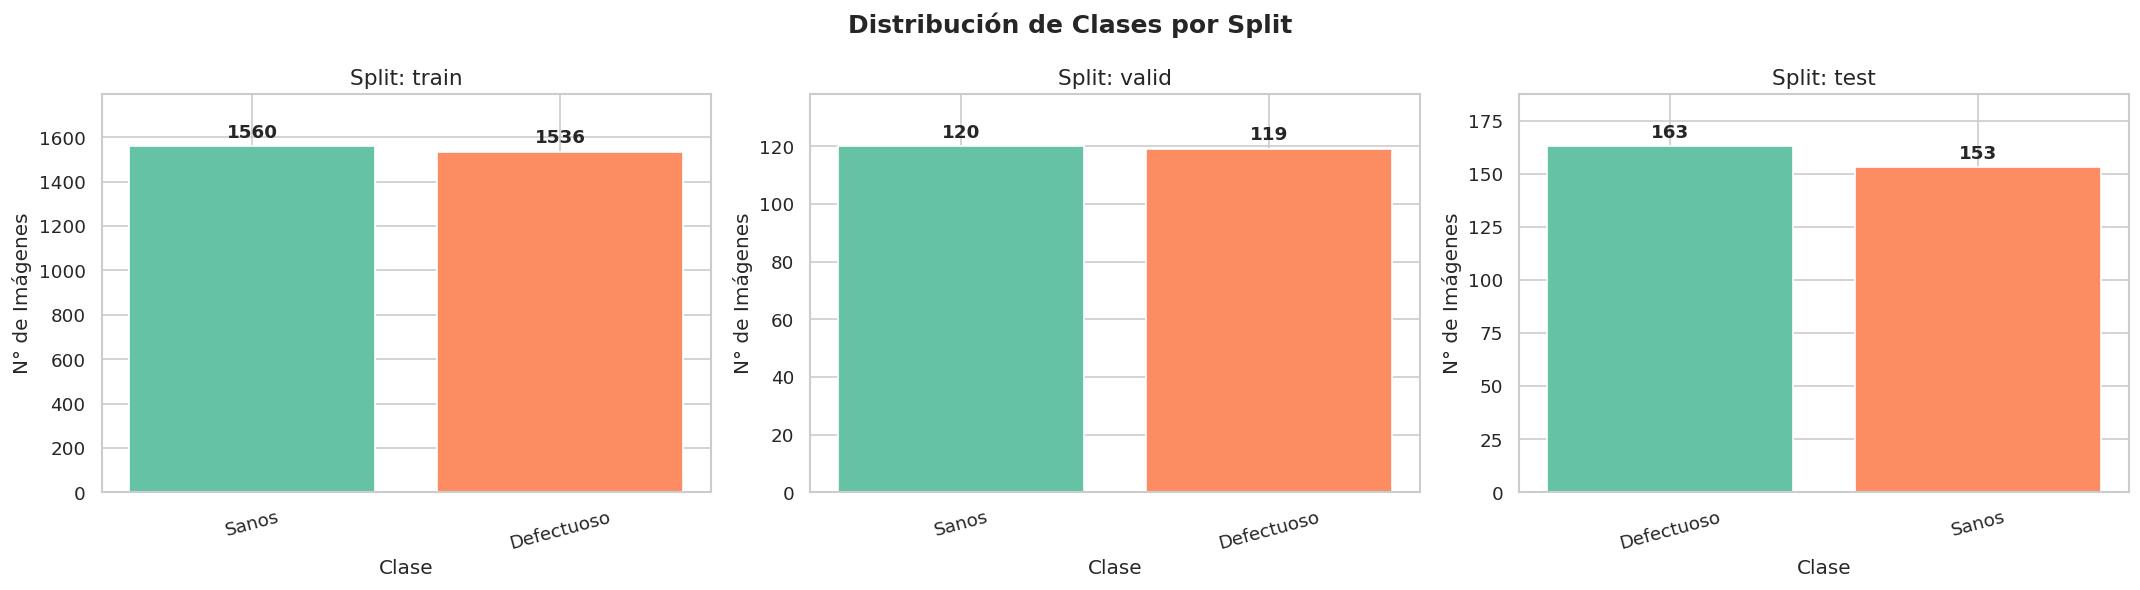


  ANÁLISIS DE DESBALANCE

[train]  Ratio max/min = 1.02  →   Balanceado
    Sanos                      1560 imgs  (50.4%)
    Defectuoso                 1536 imgs  (49.6%)

[valid]  Ratio max/min = 1.01  →   Balanceado
    Sanos                       120 imgs  (50.2%)
    Defectuoso                  119 imgs  (49.8%)

[test]  Ratio max/min = 1.07  →   Balanceado
    Defectuoso                  163 imgs  (51.6%)
    Sanos                       153 imgs  (48.4%)


In [ ]:
# ── BALANCE DE CLASES ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Distribución de Clases por Split", fontsize=15, fontweight="bold")

class_names = df_inv["clase"].unique()
colors = sns.color_palette("Set2", len(class_names))

for ax, split in zip(axes, SPLITS):
    subset = df_inv[df_inv["split"] == split]
    counts = subset["clase"].value_counts()
    if counts.empty:
        ax.set_title(f"{split} (sin datos)")
        continue
    bars = ax.bar(counts.index, counts.values, color=colors[:len(counts)])
    ax.bar_label(bars, padding=3, fontsize=11, fontweight="bold")
    ax.set_title(f"Split: {split}", fontsize=13)
    ax.set_xlabel("Clase")
    ax.set_ylabel("N° de Imágenes")
    ax.set_ylim(0, counts.max() * 1.15)
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

# ── Ratio de desbalance ────────────────────────────────────────────────────────
print("\n" + "="*55)
print("  ANÁLISIS DE DESBALANCE")
print("="*55)

for split in SPLITS:
    subset = df_inv[df_inv["split"] == split]
    if subset.empty: continue
    counts = subset["clase"].value_counts()
    ratio = counts.max() / counts.min() if counts.min() > 0 else float("inf")
    estado = " Balanceado" if ratio < 1.5 else (" Moderadamente desbalanceado" if ratio < 3 else " Muy desbalanceado")
    print(f"\n[{split}]  Ratio max/min = {ratio:.2f}  →  {estado}")
    for cls, n in counts.items():
        pct = n / counts.sum() * 100
        print(f"    {cls:<25} {n:>5} imgs  ({pct:.1f}%)")


## **5.** Análisis de Dimensiones y Resolución

Resoluciones encontradas:
resolucion
224x224    839

 Todas las imágenes tienen la misma resolución: 224x224


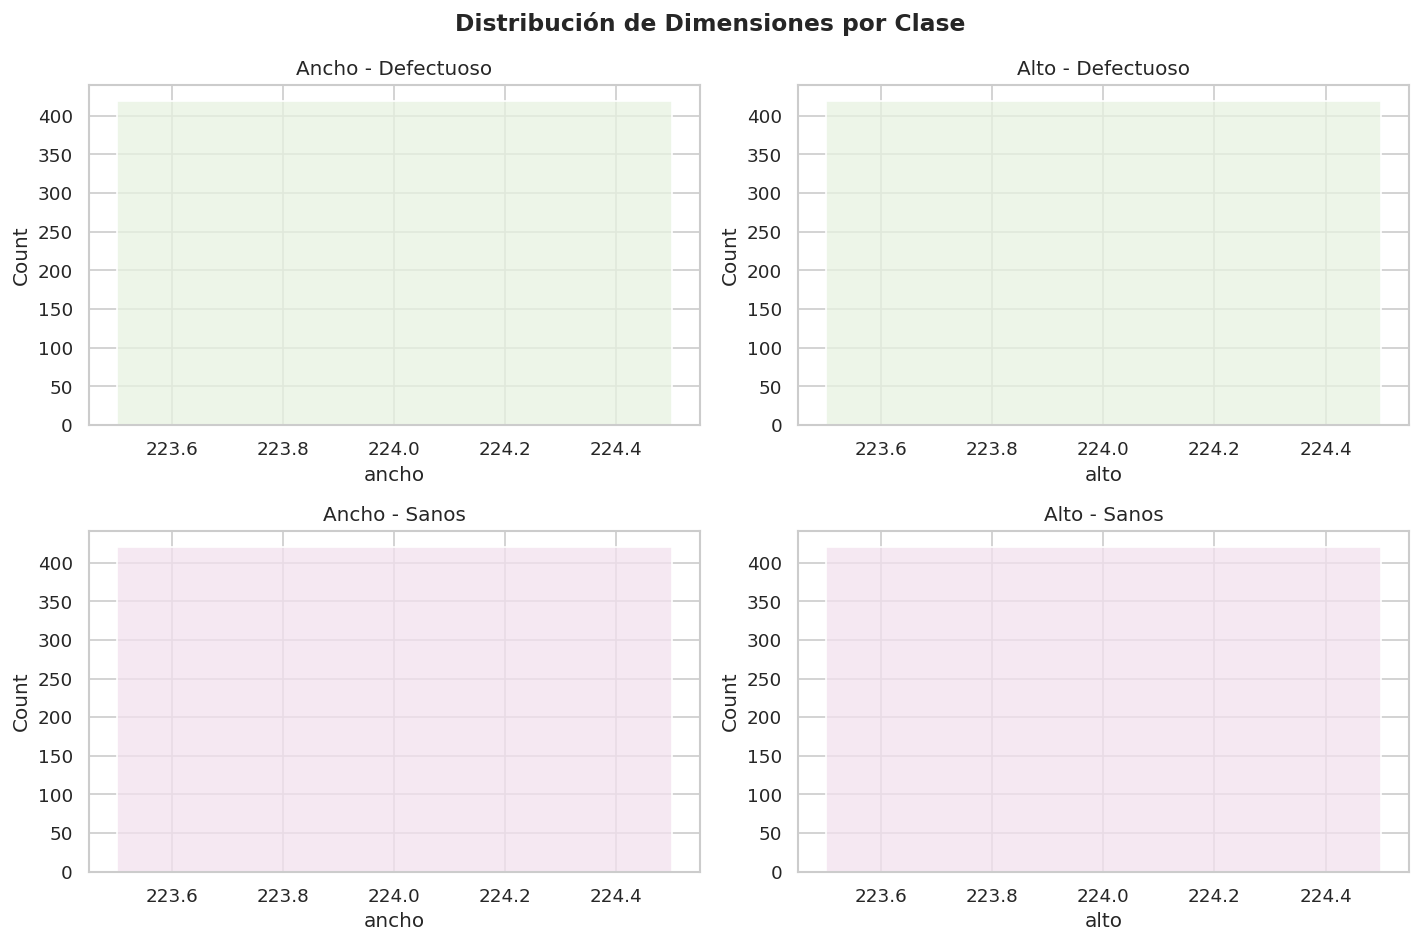


Estadísticas de resolución:
        alto  ancho  megapixels  aspect_ratio
count  839.0  839.0      839.00         839.0
mean   224.0  224.0        0.05           1.0
std      0.0    0.0        0.00           0.0
min    224.0  224.0        0.05           1.0
25%    224.0  224.0        0.05           1.0
50%    224.0  224.0        0.05           1.0
75%    224.0  224.0        0.05           1.0
max    224.0  224.0        0.05           1.0


In [ ]:
# ── DIMENSIONES ───────────────────────────────────────────────────────────────
dim_data = []
SAMPLE_PER_CLASS = 150   # imágenes a muestrear por clase

for split in SPLITS:
    for cls in df_inv["clase"].unique():
        paths = df_inv[(df_inv["split"]==split) & (df_inv["clase"]==cls)]["ruta"].tolist()
        for p in paths[:SAMPLE_PER_CLASS]:
            try:
                img = cv2.imread(p)
                if img is None: continue
                h, w = img.shape[:2]
                dim_data.append({"split": split, "clase": cls,
                                  "alto": h, "ancho": w,
                                  "resolucion": f"{w}x{h}",
                                  "aspect_ratio": round(w/h, 2),
                                  "megapixels": round(h*w/1e6, 3),
                                  "ruta": p})
            except: pass

df_dim = pd.DataFrame(dim_data)

print("Resoluciones encontradas:")
print(df_dim["resolucion"].value_counts().head(10).to_string())

unique_res = df_dim["resolucion"].nunique()
if unique_res == 1:
    print(f"\n Todas las imágenes tienen la misma resolución: {df_dim['resolucion'].iloc[0]}")
else:
    print(f"\n Se encontraron {unique_res} resoluciones distintas — se recomienda estandarizar.")

# Colores personalizados
palette = {
    "Defectuoso": "#E7F2E1",  # verde pastel
    "Sanos": "#F2E1EE"        # rosa pastel
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Distribución de Dimensiones por Clase", fontsize=14, fontweight="bold")

clases = df_dim["clase"].unique()

for i, cls in enumerate(clases):
    subset = df_dim[df_dim["clase"] == cls]

    sns.histplot(
        subset["ancho"],
        ax=axes[i,0],
        color=palette.get(cls, "gray")
    )
    axes[i,0].set_title(f"Ancho - {cls}")

    sns.histplot(
        subset["alto"],
        ax=axes[i,1],
        color=palette.get(cls, "gray")
    )
    axes[i,1].set_title(f"Alto - {cls}")

plt.tight_layout()
plt.show()

print("\nEstadísticas de resolución:")
print(df_dim[["alto","ancho","megapixels","aspect_ratio"]].describe().round(2).to_string())

## **6.** Calidad de Imagen: Brillo, Nitidez, Contraste y Ruido

Calculando métricas de calidad...


  0%|          | 0/300 [00:00<?, ?it/s]


✅ 300 imágenes analizadas.


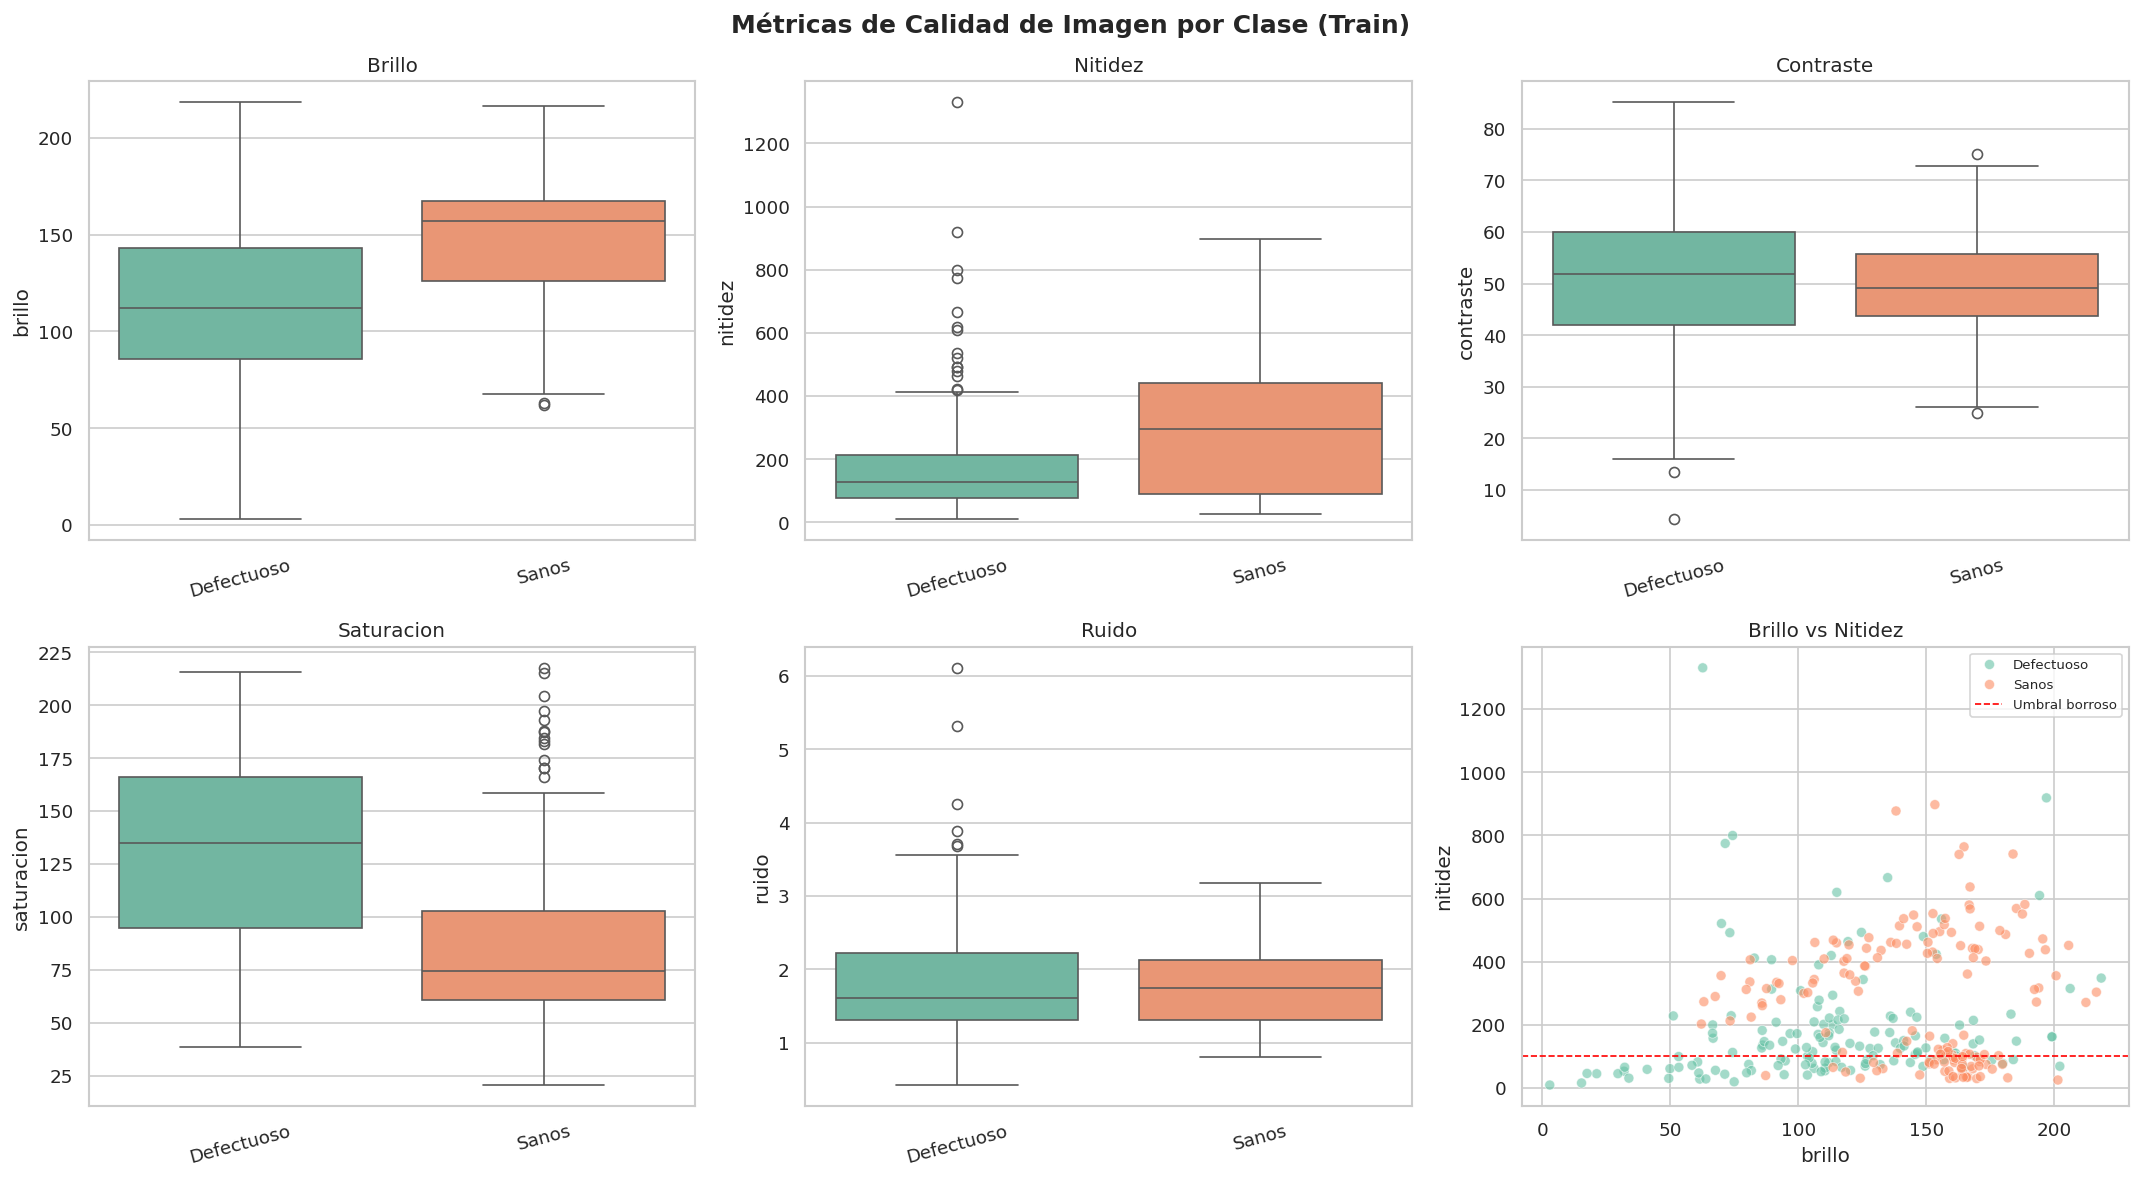


Resumen estadístico por clase:
            brillo  nitidez  contraste  saturacion  ruido
clase                                                    
Defectuoso  112.93   184.90      49.88      132.51   1.83
Sanos       147.04   281.65      50.06       88.75   1.71


In [ ]:
# ── CALIDAD DE IMAGEN ─────────────────────────────────────────────────────────
quality_data = []

# Usamos el DataFrame de dimensiones ya cargado (df_dim) para no releer
sample_paths = df_dim[df_dim["split"]=="train"].copy()

print("Calculando métricas de calidad...")
for _, row in tqdm(sample_paths.iterrows(), total=len(sample_paths)):
    try:
        img = cv2.imread(row["ruta"])
        if img is None: continue

        # ─── Brillo (canal V del HSV)
        hsv        = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        brightness = hsv[:,:,2].mean()

        # ─── Saturación (canal S)
        saturation = hsv[:,:,1].mean()

        # ─── Nitidez (varianza laplaciana)
        gray        = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        sharpness   = cv2.Laplacian(gray, cv2.CV_64F).var()

        # ─── Contraste (std del canal gris)
        contrast    = gray.std()

        # ─── Ruido estimado (diferencia vs Gaussiano suavizado)
        blur        = cv2.GaussianBlur(gray, (5,5), 0)
        noise       = np.abs(gray.astype(float) - blur.astype(float)).mean()

        # ─── Sobreexposición / Subexposición
        overexp  = (gray > 240).mean() * 100   # % píxeles quemados
        underexp = (gray < 15).mean()  * 100   # % píxeles negros

        quality_data.append({
            "clase": row["clase"],
            "brillo":     round(brightness, 2),
            "saturacion": round(saturation, 2),
            "nitidez":    round(sharpness, 2),
            "contraste":  round(contrast, 2),
            "ruido":      round(noise, 2),
            "sobreexp_%": round(overexp, 2),
            "subexp_%":   round(underexp, 2),
            "ruta": row["ruta"]
        })
    except Exception as e:
        pass

df_q = pd.DataFrame(quality_data)
print(f"\n✅ {len(df_q)} imágenes analizadas.")

# ── Visualización ──────────────────────────────────────────────────────────────
metrics = ["brillo", "nitidez", "contraste", "saturacion", "ruido"]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Métricas de Calidad de Imagen por Clase (Train)", fontsize=15, fontweight="bold")

for ax, metric in zip(axes.flatten(), metrics):
    sns.boxplot(data=df_q, x="clase", y=metric, palette="Set2", ax=ax)
    ax.set_title(metric.capitalize(), fontsize=12)
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=15)

# Scatter brillo vs nitidez
ax = axes.flatten()[-1]
sns.scatterplot(data=df_q, x="brillo", y="nitidez", hue="clase",
                alpha=0.6, ax=ax)
ax.axhline(100, color="red", linestyle="--", linewidth=1, label="Umbral borroso")
ax.set_title("Brillo vs Nitidez")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ── Resumen estadístico ────────────────────────────────────────────────────────
print("\nResumen estadístico por clase:")
print(df_q.groupby("clase")[metrics].mean().round(2).to_string())


## 8️⃣ Análisis de Color — Histogramas y Espacio HSV

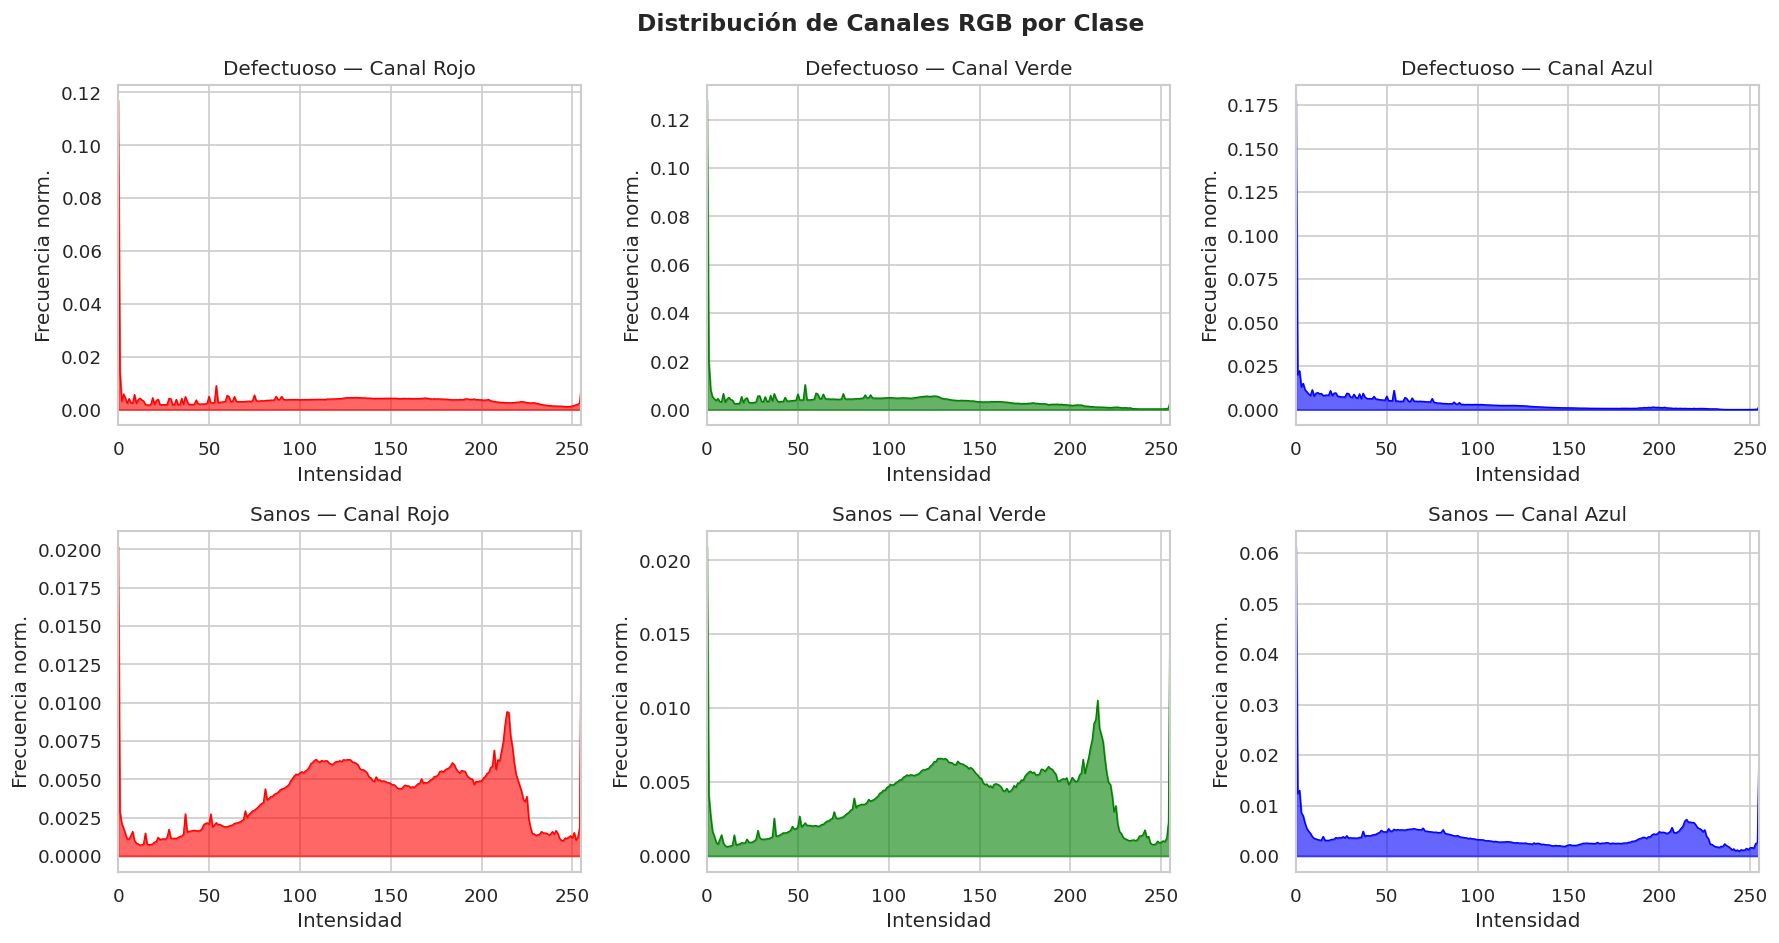

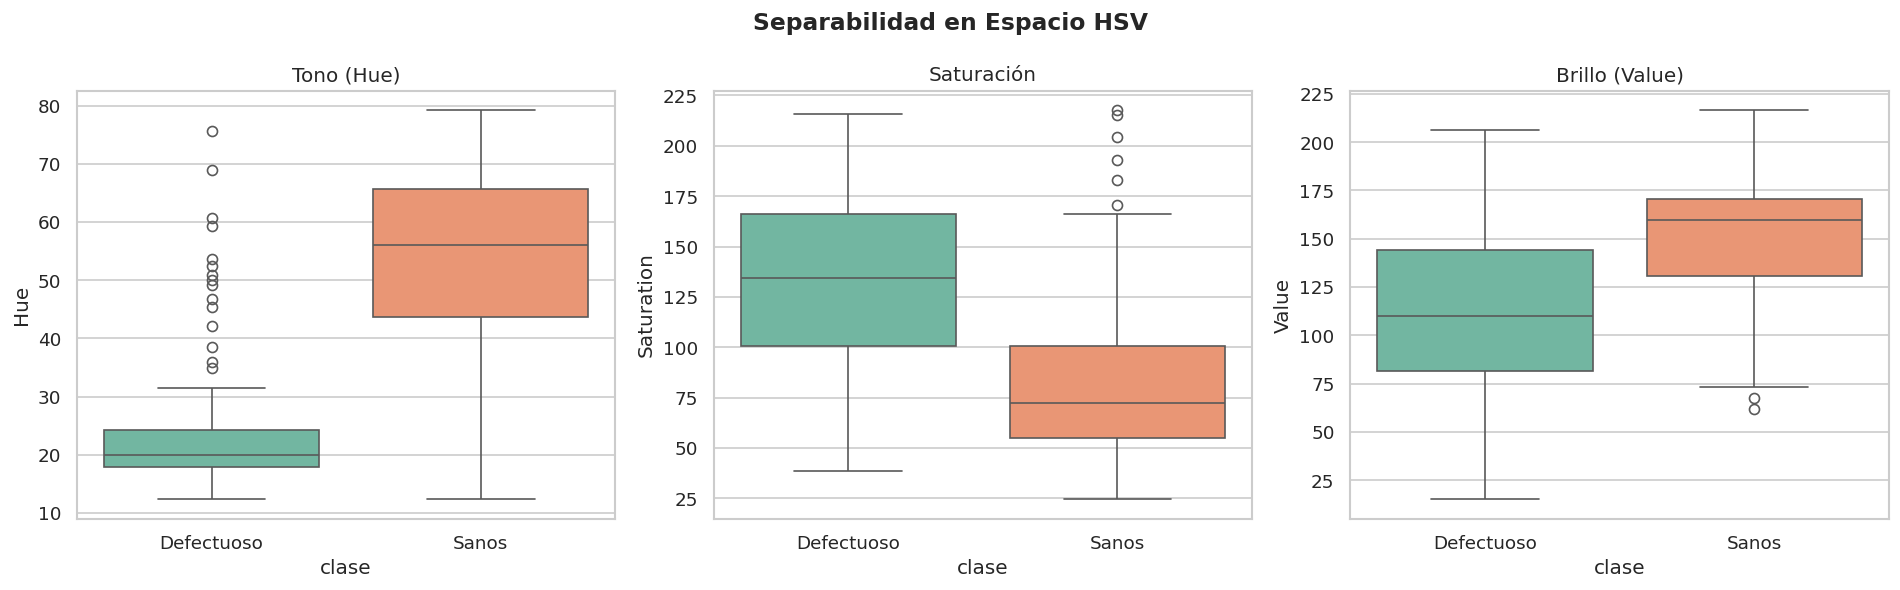

In [ ]:
# ── HISTOGRAMAS DE COLOR POR CLASE ────────────────────────────────────────────
classes = df_inv["clase"].unique()
n_cls   = len(classes)

fig, axes = plt.subplots(n_cls, 3, figsize=(15, 4*n_cls))
fig.suptitle("Distribución de Canales RGB por Clase", fontsize=14, fontweight="bold")
if n_cls == 1: axes = axes.reshape(1,-1)

canal_cfg = [("Rojo", "red"), ("Verde", "green"), ("Azul", "blue")]

for row_i, cls in enumerate(classes):
    paths = df_inv[(df_inv["clase"]==cls) & (df_inv["split"]=="train")]["ruta"].tolist()[:80]
    hist_acc = [np.zeros(256) for _ in range(3)]

    for p in paths:
        img = cv2.imread(p)
        if img is None: continue
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        for ch in range(3):
            h, _ = np.histogram(img_rgb[:,:,ch], bins=256, range=(0,256))
            hist_acc[ch] += h

    for col_i, (canal, color) in enumerate(canal_cfg):
        ax = axes[row_i][col_i]
        hist_norm = hist_acc[col_i] / hist_acc[col_i].sum()
        ax.fill_between(range(256), hist_norm, alpha=0.6, color=color)
        ax.plot(range(256), hist_norm, color=color, linewidth=0.8)
        ax.set_title(f"{cls} — Canal {canal}")
        ax.set_xlim(0, 255)
        ax.set_xlabel("Intensidad")
        ax.set_ylabel("Frecuencia norm.")

plt.tight_layout()
plt.show()

# ── Espacio de color HSV: separabilidad entre clases ─────────────────────────
hsv_data = []
for cls in classes:
    paths = df_inv[(df_inv["clase"]==cls) & (df_inv["split"]=="train")]["ruta"].tolist()[:80]
    for p in paths:
        img = cv2.imread(p)
        if img is None: continue
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        hsv_data.append({"clase": cls,
                          "Hue": hsv[:,:,0].mean(),
                          "Saturation": hsv[:,:,1].mean(),
                          "Value": hsv[:,:,2].mean()})

df_hsv = pd.DataFrame(hsv_data)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Separabilidad en Espacio HSV", fontsize=14, fontweight="bold")
sns.boxplot(data=df_hsv, x="clase", y="Hue",        palette="Set2", ax=axes[0]); axes[0].set_title("Tono (Hue)")
sns.boxplot(data=df_hsv, x="clase", y="Saturation", palette="Set2", ax=axes[1]); axes[1].set_title("Saturación")
sns.boxplot(data=df_hsv, x="clase", y="Value",      palette="Set2", ax=axes[2]); axes[2].set_title("Brillo (Value)")
plt.tight_layout()
plt.show()


## 🔟 Reducción Dimensional — PCA y t-SNE

Extrayendo características para PCA/t-SNE...


Defectuoso:   0%|          | 0/200 [00:00<?, ?it/s]

Sanos:   0%|          | 0/200 [00:00<?, ?it/s]

Calculando t-SNE (puede tomar ~1 min)...


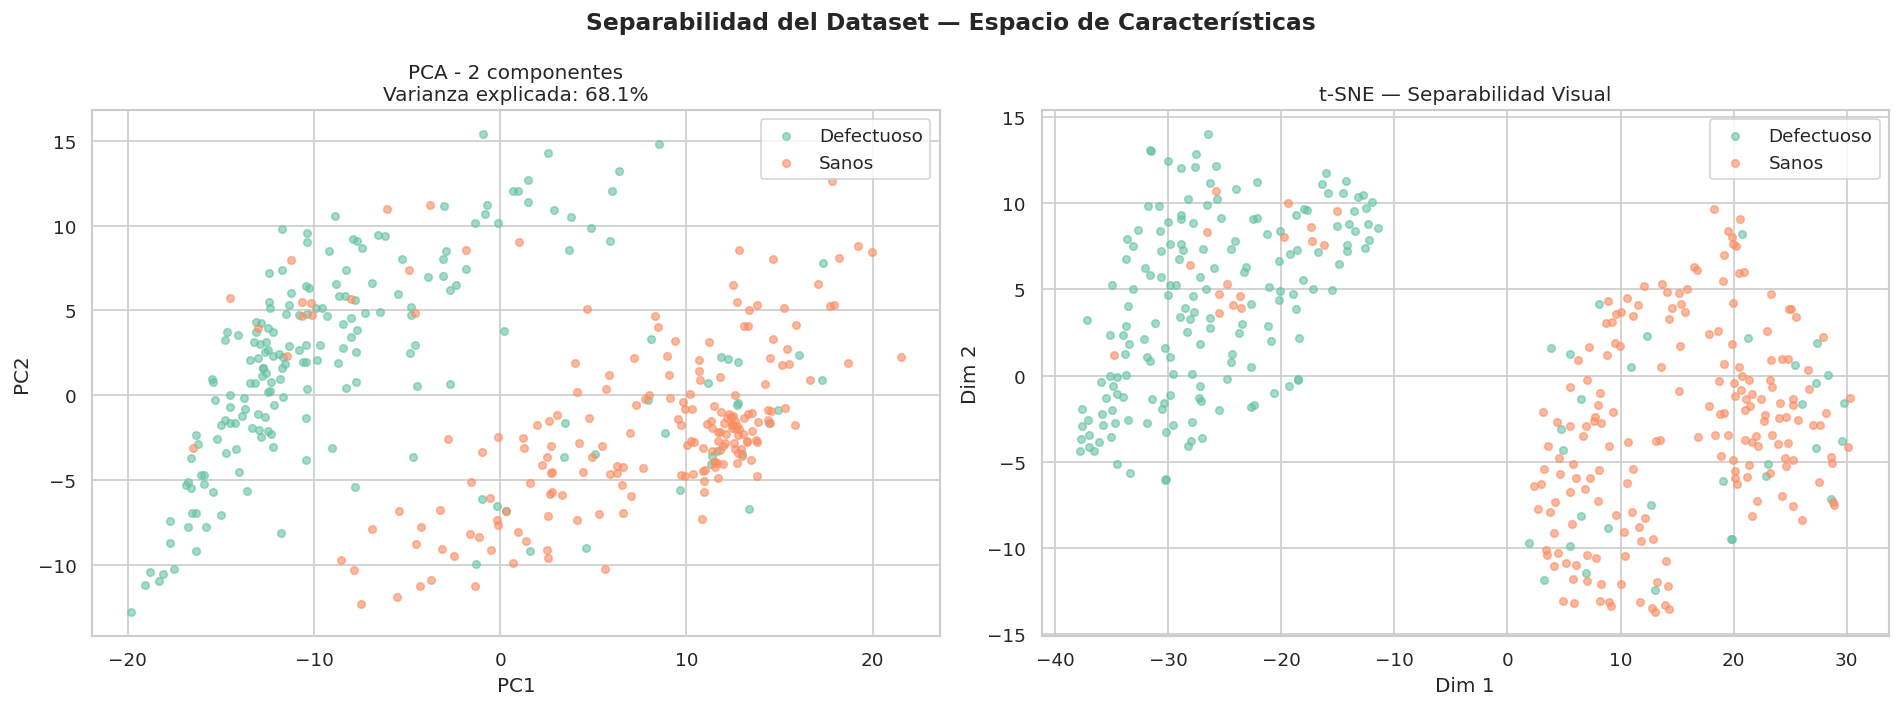

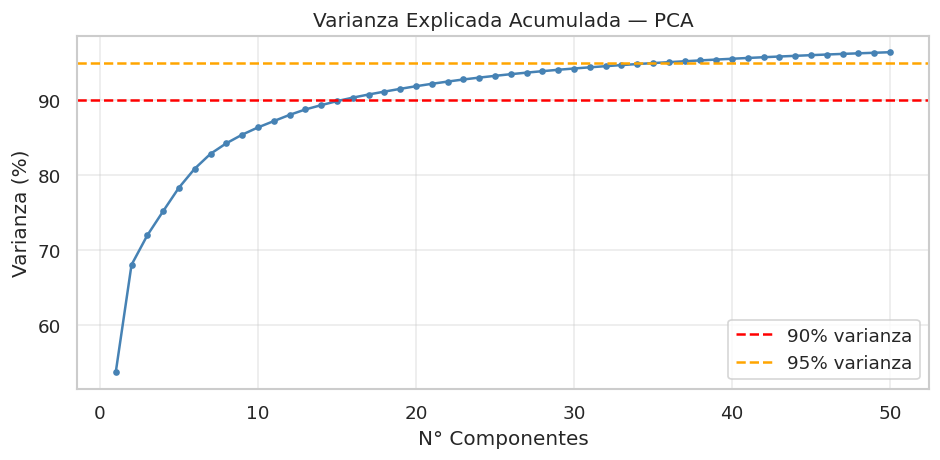

In [ ]:
# ── PCA + t-SNE ───────────────────────────────────────────────────────────────
FEAT_SAMPLE = 200   # imágenes por clase para el análisis

def extract_features(img_path, size=(64,64)):
    """Extrae vector de características simples (histograma RGB flattened + HOG básico)."""
    img = cv2.imread(img_path)
    if img is None: return None
    img_resized = cv2.resize(img, size)
    img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
    # Histograma RGB de 16 bins por canal
    feats = []
    for ch in range(3):
        h, _ = np.histogram(img_rgb[:,:,ch], bins=16, range=(0,256))
        feats.extend(h / h.sum())
    # Pixel values flattened (64x64x3 → 12288) — reducimos a 32x32
    small = cv2.resize(img_rgb, (32,32)).flatten() / 255.0
    feats.extend(small)
    return np.array(feats, dtype=np.float32)

print("Extrayendo características para PCA/t-SNE...")
feat_list, label_list = [], []
for cls in classes:
    paths = df_inv[(df_inv["clase"]==cls) & (df_inv["split"]=="train")]["ruta"].tolist()[:FEAT_SAMPLE]
    for p in tqdm(paths, desc=cls, leave=False):
        f = extract_features(p)
        if f is not None:
            feat_list.append(f)
            label_list.append(cls)

X = np.array(feat_list)
le = LabelEncoder()
y = le.fit_transform(label_list)

# ── PCA ───────────────────────────────────────────────────────────────────────
pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Separabilidad del Dataset — Espacio de Características", fontsize=14, fontweight="bold")

# PCA 2D
scatter_colors = sns.color_palette("Set2", len(classes))
for i, cls in enumerate(le.classes_):
    mask = y == i
    axes[0].scatter(X_pca[mask,0], X_pca[mask,1],
                    c=[scatter_colors[i]], label=cls, alpha=0.6, s=20)
axes[0].set_title("PCA - 2 componentes\nVarianza explicada: {:.1f}%".format(pca.explained_variance_ratio_[:2].sum()*100))
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
axes[0].legend()

# t-SNE (más lento pero mejor visualización)
print("Calculando t-SNE (puede tomar ~1 min)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(X)-1),
            n_iter=1000, learning_rate="auto", init="pca")
X_tsne = tsne.fit_transform(X_pca[:, :20])

for i, cls in enumerate(le.classes_):
    mask = y == i
    axes[1].scatter(X_tsne[mask,0], X_tsne[mask,1],
                    c=[scatter_colors[i]], label=cls, alpha=0.6, s=20)
axes[1].set_title("t-SNE — Separabilidad Visual")
axes[1].set_xlabel("Dim 1"); axes[1].set_ylabel("Dim 2")
axes[1].legend()

plt.tight_layout()
plt.show()

# ── Varianza explicada PCA ─────────────────────────────────────────────────────
plt.figure(figsize=(8,4))
cum_var = np.cumsum(pca.explained_variance_ratio_) * 100
plt.plot(range(1, len(cum_var)+1), cum_var, marker="o", markersize=3, color="steelblue")
plt.axhline(90, color="red", linestyle="--", label="90% varianza")
plt.axhline(95, color="orange", linestyle="--", label="95% varianza")
plt.title("Varianza Explicada Acumulada — PCA"); plt.xlabel("N° Componentes"); plt.ylabel("Varianza (%)")
plt.legend(); plt.grid(True, alpha=0.4); plt.tight_layout(); plt.show()
